#  Problem Statement:
Use a relevant machine learning model to predict  whether an insurance claim will be approved or denied.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

In [2]:
data=pd.read_csv('train.csv')

In [3]:
data

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595207,1488013,0,3,1,10,0,0,0,0,0,...,4,1,9,6,0,1,1,0,1,1
595208,1488016,0,5,1,3,0,0,0,0,0,...,4,1,3,8,1,0,1,0,1,1
595209,1488017,0,1,1,10,0,0,1,0,0,...,3,2,2,6,0,0,1,0,0,0
595210,1488021,0,5,2,3,1,0,0,0,1,...,4,1,4,2,0,1,1,1,0,0


# Domain Analysis:

- The insurance industry relies heavily on targeted marketing to acquire and retain customers.
- understanding customer behavior and predicting which customers are likely to purchase .

## Basic Check

In [5]:
data.head(pd.set_option('display.max_columns',None))#first five rows

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,0,0,0,0,0,0,11,0,1,0,0.7,0.2,0.718070,10,1,-1,0,1,4,1,0,0,1,12,2,0.400000,0.883679,0.370810,3.605551,0.6,0.5,0.2,3,1,10,1,10,1,5,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,0,0,0,0,0,0,3,0,0,1,0.8,0.4,0.766078,11,1,-1,0,-1,11,1,1,2,1,19,3,0.316228,0.618817,0.388716,2.449490,0.3,0.1,0.3,2,1,9,5,8,1,7,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,0,0,0,0,0,0,12,1,0,0,0.0,0.0,-1.000000,7,1,-1,0,-1,14,1,1,2,1,60,1,0.316228,0.641586,0.347275,3.316625,0.5,0.7,0.1,2,2,9,1,8,2,7,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,0,0,0,0,0,0,8,1,0,0,0.9,0.2,0.580948,7,1,0,0,1,11,1,1,3,1,104,1,0.374166,0.542949,0.294958,2.000000,0.6,0.9,0.1,2,4,7,1,8,4,2,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,0,0,0,0,0,0,9,1,0,0,0.7,0.6,0.840759,11,1,-1,0,-1,14,1,1,2,1,82,3,0.316070,0.565832,0.365103,2.000000,0.4,0.6,0.0,2,2,6,3,10,2,12,3,1,1,3,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595207,1488013,0,3,1,10,0,0,0,0,0,1,0,0,0,0,0,13,1,0,0,0.5,0.3,0.692820,10,1,-1,0,1,1,1,1,0,1,31,3,0.374166,0.684631,0.385487,2.645751,0.4,0.5,0.3,3,0,9,0,9,1,12,4,1,9,6,0,1,1,0,1,1
595208,1488016,0,5,1,3,0,0,0,0,0,1,0,0,0,0,0,6,1,0,0,0.9,0.7,1.382027,9,1,-1,0,-1,15,0,0,2,1,63,2,0.387298,0.972145,-1.000000,3.605551,0.2,0.2,0.0,2,4,8,6,8,2,12,4,1,3,8,1,0,1,0,1,1
595209,1488017,0,1,1,10,0,0,1,0,0,0,0,0,0,0,0,12,1,0,0,0.9,0.2,0.659071,7,1,-1,0,-1,1,1,1,2,1,31,3,0.397492,0.596373,0.398748,1.732051,0.4,0.0,0.3,3,2,7,4,8,0,10,3,2,2,6,0,0,1,0,0,0
595210,1488021,0,5,2,3,1,0,0,0,1,0,0,0,0,0,0,12,1,0,0,0.9,0.4,0.698212,11,1,-1,0,-1,11,1,1,2,1,101,3,0.374166,0.764434,0.384968,3.162278,0.0,0.7,0.0,4,0,9,4,9,2,11,4,1,4,2,0,1,1,1,0,0


In [6]:
data.tail(5)

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
595207,1488013,0,3,1,10,0,0,0,0,0,1,0,0,0,0,0,13,1,0,0,0.5,0.3,0.692820,10,1,-1,0,1,1,1,1,0,1,31,3,0.374166,0.684631,0.385487,2.645751,0.4,0.5,0.3,3,0,9,0,9,1,12,4,1,9,6,0,1,1,0,1,1
595208,1488016,0,5,1,3,0,0,0,0,0,1,0,0,0,0,0,6,1,0,0,0.9,0.7,1.382027,9,1,-1,0,-1,15,0,0,2,1,63,2,0.387298,0.972145,-1.000000,3.605551,0.2,0.2,0.0,2,4,8,6,8,2,12,4,1,3,8,1,0,1,0,1,1
595209,1488017,0,1,1,10,0,0,1,0,0,0,0,0,0,0,0,12,1,0,0,0.9,0.2,0.659071,7,1,-1,0,-1,1,1,1,2,1,31,3,0.397492,0.596373,0.398748,1.732051,0.4,0.0,0.3,3,2,7,4,8,0,10,3,2,2,6,0,0,1,0,0,0
595210,1488021,0,5,2,3,1,0,0,0,1,0,0,0,0,0,0,12,1,0,0,0.9,0.4,0.698212,11,1,-1,0,-1,11,1,1,2,1,101,3,0.374166,0.764434,0.384968,3.162278,0.0,0.7,0.0,4,0,9,4,9,2,11,4,1,4,2,0,1,1,1,0,0
595211,1488027,0,0,1,8,0,0,1,0,0,0,0,0,0,0,0,7,1,0,0,0.1,0.2,-1.000000,7,0,-1,0,-1,0,1,0,2,1,34,2,0.400000,0.932649,0.378021,3.741657,0.4,0.0,0.5,2,3,10,4,10,2,5,4,4,3,8,0,1,0,0,0,0


In [7]:
data.describe()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,5.952120e+05,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,7.438036e+05,0.036448,1.900378,1.358943,4.423318,0.416794,0.405188,0.393742,0.257033,0.163921,0.185304,0.000373,0.001692,0.009439,0.000948,0.012451,7.299922,0.660823,0.121081,0.153446,0.610991,0.439184,0.551102,8.295933,0.829931,-0.504899,0.725192,-0.157732,6.555340,0.910027,0.832080,1.328890,0.992136,62.215674,2.346072,0.379945,0.813265,0.276256,3.065899,0.449756,0.449589,0.449849,2.372081,1.885886,7.689445,3.005823,9.225904,2.339034,8.433590,5.441382,1.441918,2.872288,7.539026,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,4.293678e+05,0.187401,1.983789,0.664594,2.699902,0.493311,1.350642,0.488579,0.436998,0.370205,0.388544,0.019309,0.041097,0.096693,0.030768,0.127545,3.546042,0.473430,0.326222,0.360417,0.287643,0.404264,0.793506,2.508270,0.375716,0.788654,2.153463,0.844417,5.501445,0.347106,0.373796,0.978747,0.091619,33.012455,0.832548,0.058327,0.224588,0.357154,0.731366,0.287198,0.286893,0.287153,1.117219,1.134927,1.334312,1.414564,1.459672,1.246949,2.904597,2.332871,1.202963,1.694887,2.746652,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,7.000000e+00,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,1.000000,-1.000000,-1.000000,0.250619,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.719915e+05,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.400000,0.200000,0.525000,7.000000,1.000000,-1.000000,0.000000,-1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,32.000000,2.000000,0.316228,0.670867,0.333167,2.828427,0.200000,0.200000,0.200000,2.000000,1.000000,7.000000,2.000000,8.000000,1.000000,6.000000,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.435475e+05,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,1.000000,0.000000,0.000000,0.700000,0.300000,0.720677,7.000000,1.000000,-1.000000,0.000000,0.000000,7.0000

In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,595212.0,743803.558435,429367.820429,7.000000,371991.500000,743547.500000,1.115549e+06,1.488027e+06
target,595212.0,0.036448,0.187401,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00
ps_ind_01,595212.0,1.900378,1.983789,0.000000,0.000000,1.000000,3.000000e+00,7.000000e+00
ps_ind_02_cat,595212.0,1.358943,0.664594,-1.000000,1.000000,1.000000,2.000000e+00,4.000000e+00
ps_ind_03,595212.0,4.423318,2.699902,0.000000,2.000000,4.000000,6.000000e+00,1.100000e+01
ps_ind_04_cat,595212.0,0.416794,0.493311,-1.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
ps_ind_05_cat,595212.0,0.405188,1.350642,-1.000000,0.000000,0.000000,0.000000e+00,6.000000e+00
ps_ind_06_bin,595212.0,0.393742,0.488579,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
ps_ind_07_bin,595212.0,0.257033,0.436998,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
ps_ind_08_bin,595212.0,0.163921,0.370205,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00


In [9]:
data.info()#To check  data type and  null value of all columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_

In [10]:
data.isnull().sum()

id                0
target            0
ps_ind_01         0
ps_ind_02_cat     0
ps_ind_03         0
ps_ind_04_cat     0
ps_ind_05_cat     0
ps_ind_06_bin     0
ps_ind_07_bin     0
ps_ind_08_bin     0
ps_ind_09_bin     0
ps_ind_10_bin     0
ps_ind_11_bin     0
ps_ind_12_bin     0
ps_ind_13_bin     0
ps_ind_14         0
ps_ind_15         0
ps_ind_16_bin     0
ps_ind_17_bin     0
ps_ind_18_bin     0
ps_reg_01         0
ps_reg_02         0
ps_reg_03         0
ps_car_01_cat     0
ps_car_02_cat     0
ps_car_03_cat     0
ps_car_04_cat     0
ps_car_05_cat     0
ps_car_06_cat     0
ps_car_07_cat     0
ps_car_08_cat     0
ps_car_09_cat     0
ps_car_10_cat     0
ps_car_11_cat     0
ps_car_11         0
ps_car_12         0
ps_car_13         0
ps_car_14         0
ps_car_15         0
ps_calc_01        0
ps_calc_02        0
ps_calc_03        0
ps_calc_04        0
ps_calc_05        0
ps_calc_06        0
ps_calc_07        0
ps_calc_08        0
ps_calc_09        0
ps_calc_10        0
ps_calc_11        0


## Observation: There is no null values

In [11]:
data1=data.copy()

In [12]:
data1.drop(['id'],axis=1,inplace=True)

data1

In [13]:
data1.duplicated().sum()

0

## Observation: There is no duplicated values

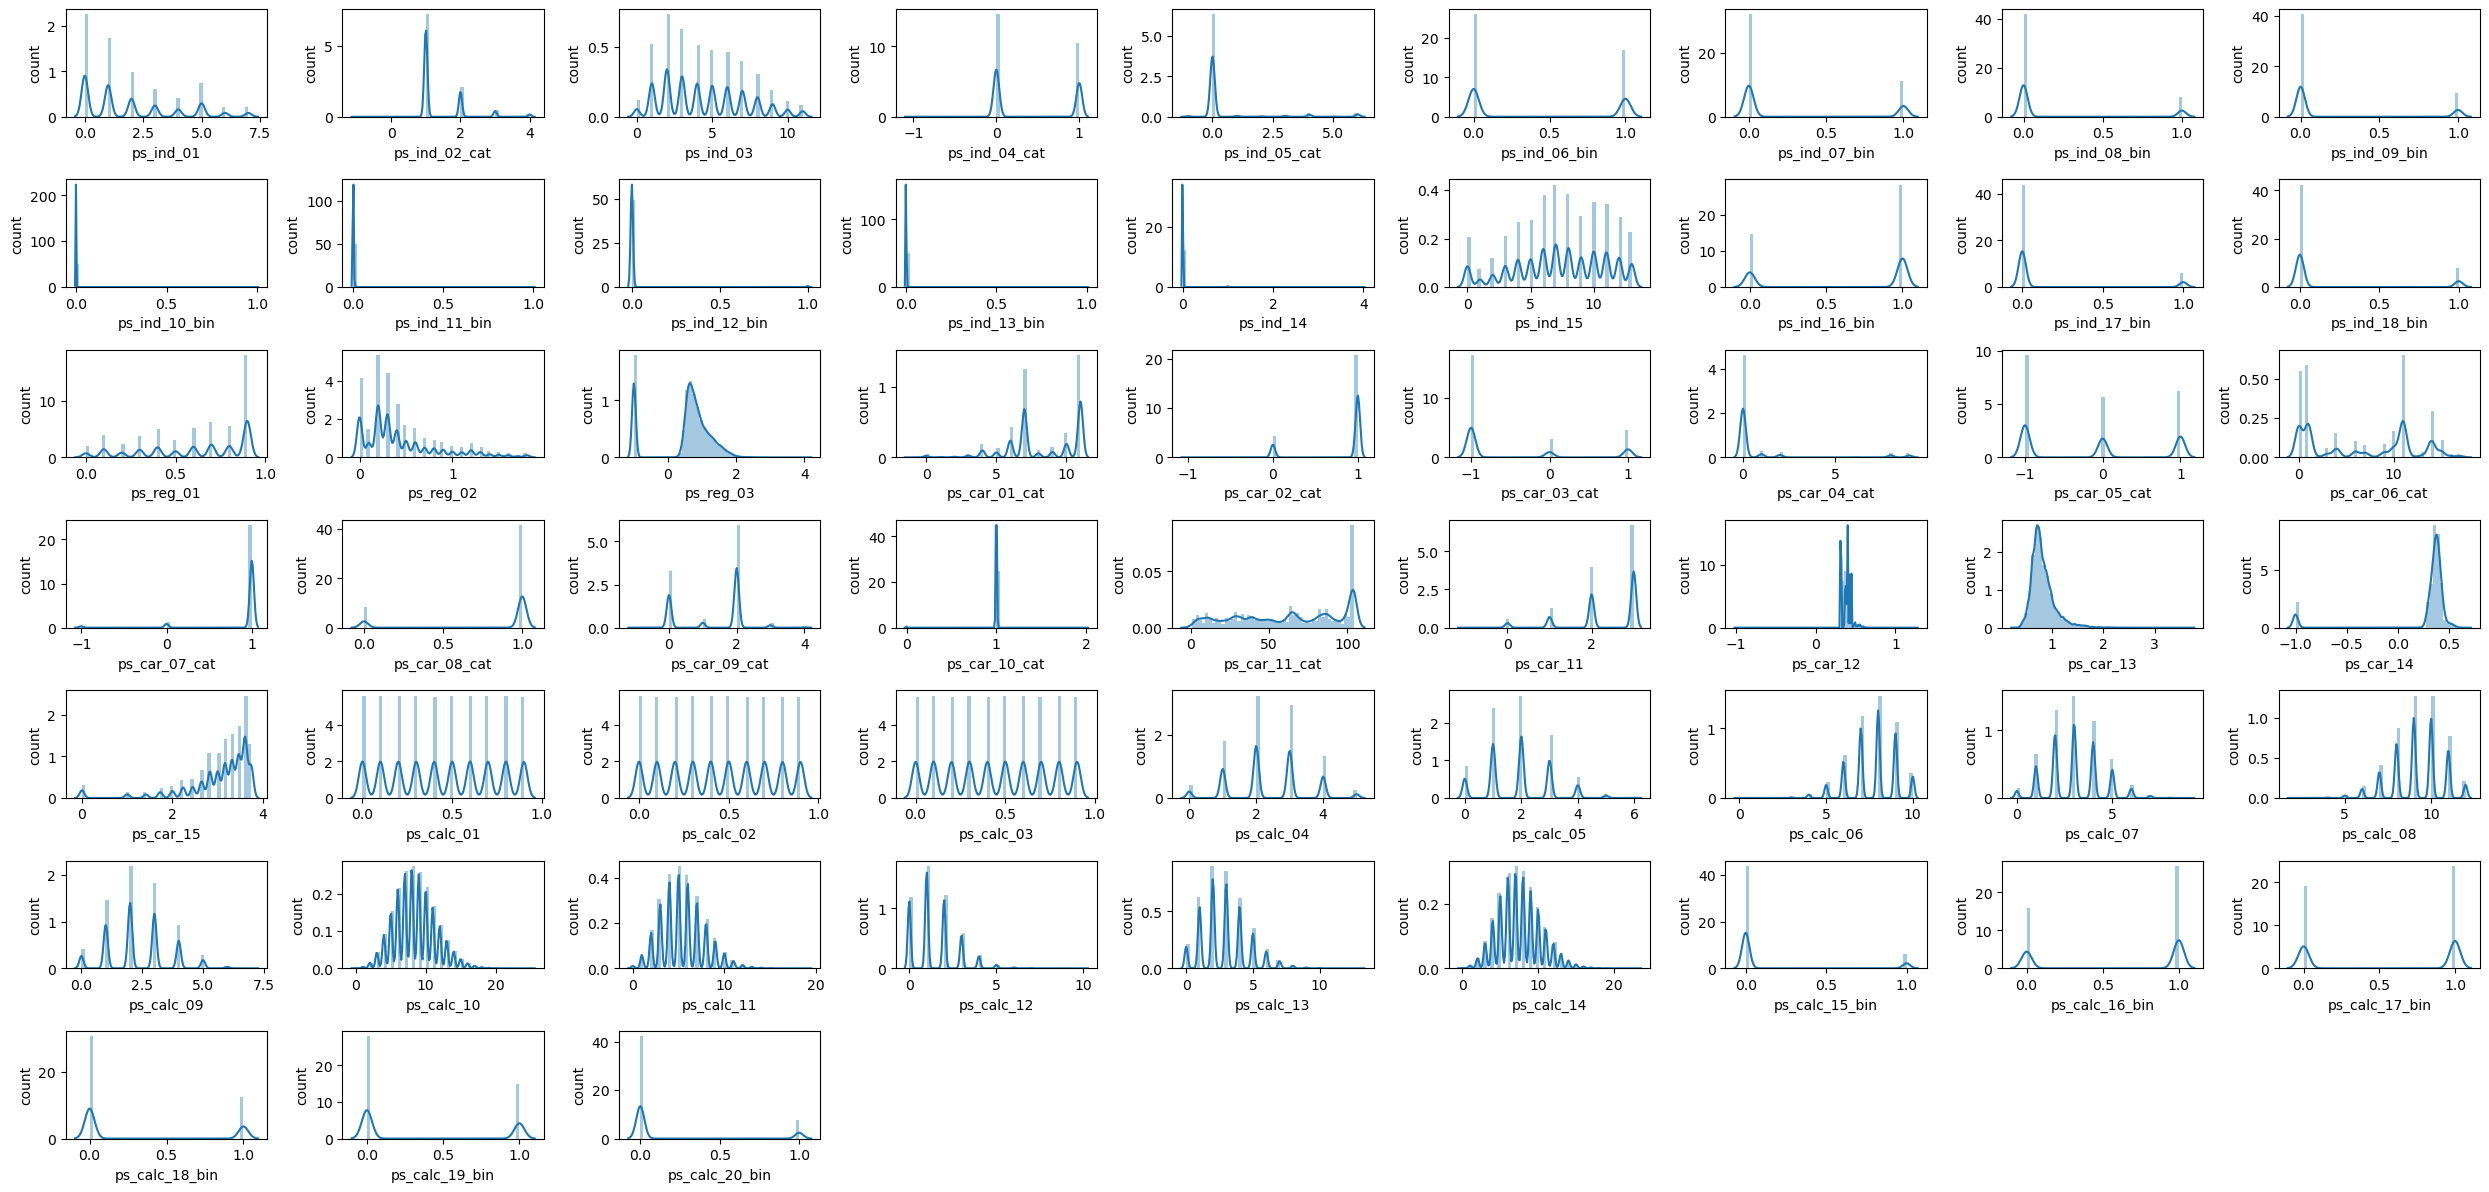

In [14]:
plt.figure(figsize=(25,15),facecolor='white')# to change the length and breadth of the canva
plotnumber=1
for i in data1.drop(columns='target',axis=1):
    if plotnumber<=57:
        ax=plt.subplot(9,9,plotnumber)
        sns.distplot(x=data1[i])
        plt.xlabel(i,fontsize=10)
        plt.ylabel("count",fontsize=10)
        plotnumber+=1
    plt.tight_layout()

## Check for outliers

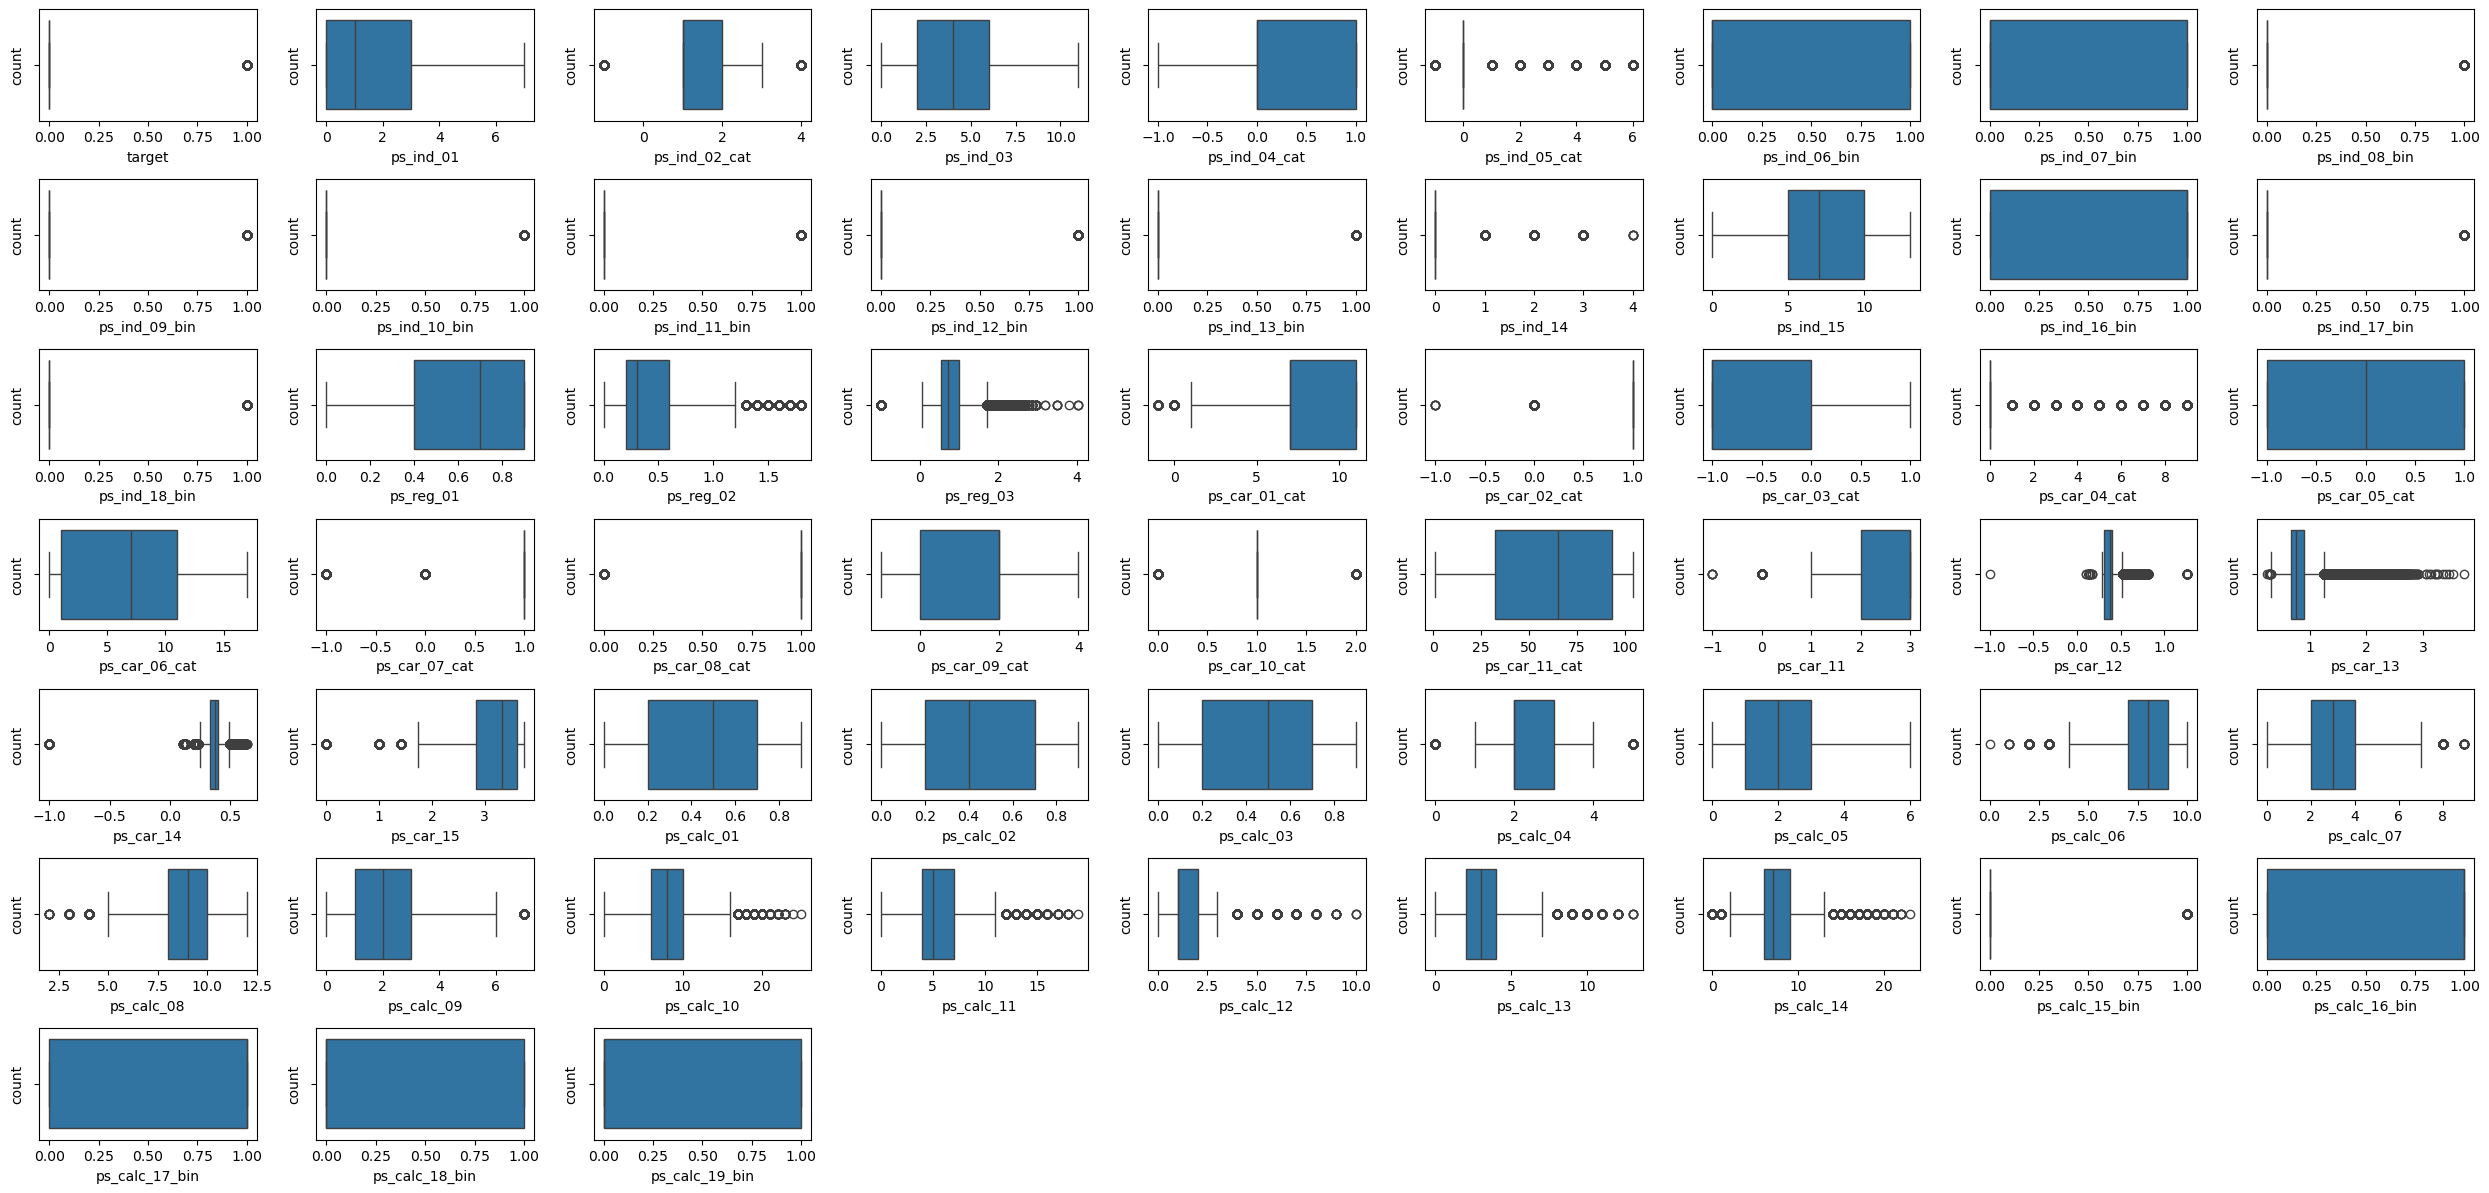

In [15]:
plt.figure(figsize=(25,15),facecolor='white')# to change the length and breadth of the canva
plotnumber=1
for i in data1:
    if plotnumber<=57:
        ax=plt.subplot(9,9,plotnumber)
        sns.boxplot(x=data1[i])
        plt.xlabel(i,fontsize=10)
        plt.ylabel("count",fontsize=10)
        plotnumber+=1
    plt.tight_layout() # without this there is overlapping

In [16]:
# First quantile (Q1) 
Q1 = data1.quantile(0.25)
# Third quantile (Q3)
Q3 = data1.quantile(0.75)
# IQR value
IQR = Q3-Q1
# Getting the limits
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
# Sum of outliers
outliers_count = ((data1 > upper_limit) | (data1 < lower_limit)).sum()
# Percentage of outliers
outliers_percentage = (outliers_count/len(data1))*100
print('Sum of Outliers: ',outliers_count)
print('Percentage of Outliers:',outliers_percentage)
filtered_columns = outliers_percentage[(outliers_percentage > 0) & (outliers_percentage < 5)]
if filtered_columns.any():
    print("Columns that need to be handled:\n", filtered_columns)

Sum of Outliers:  target             21694
ps_ind_01              0
ps_ind_02_cat      11594
ps_ind_03              0
ps_ind_04_cat          0
ps_ind_05_cat      67203
ps_ind_06_bin          0
ps_ind_07_bin          0
ps_ind_08_bin      97568
ps_ind_09_bin     110295
ps_ind_10_bin        222
ps_ind_11_bin       1007
ps_ind_12_bin       5618
ps_ind_13_bin        564
ps_ind_14           6380
ps_ind_15              0
ps_ind_16_bin          0
ps_ind_17_bin      72069
ps_ind_18_bin      91333
ps_reg_01              0
ps_reg_02          36793
ps_reg_03         120865
ps_car_01_cat       6011
ps_car_02_cat     101222
ps_car_03_cat          0
ps_car_04_cat      98631
ps_car_05_cat          0
ps_car_06_cat          0
ps_car_07_cat      42064
ps_car_08_cat      99948
ps_car_09_cat          0
ps_car_10_cat       5033
ps_car_11_cat          0
ps_car_11          25988
ps_car_12          15356
ps_car_13          26913
ps_car_14          58905
ps_car_15          27409
ps_calc_01             0
ps_calc

## Analysing Box Plot
By analysing box plot above not handled outliers from below columns :
- ps_ind_02_cat
- ps_ind_10_bin
- ps_ind_11_bin
- ps_ind_12_bin
- ps_ind_13_bin
- ps_ind_14 
- ps_car_10_cat 
- It has low frequencies and not suitable for handling outliers

In [17]:
columns=[
     'ps_car_01_cat', 'ps_car_11','ps_car_12','ps_car_13','ps_car_15','ps_calc_06',
     'ps_calc_07','ps_calc_08','ps_calc_09','ps_calc_10','ps_calc_11','ps_calc_13','ps_calc_14']        
# Iterate over each column in the DataFrame
for col in columns:
   
   
    # Get the median of the column (excluding NaN values)
    column_median = data1[col].median()
    # Calculate quantiles for the current column only
    Q1 = data1[col].quantile(0.25)
    Q3 = data1[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    # Replace outliers with the median value of the column
    # Use .loc to ensure index alignment
    data1.loc[(data1[col] < lower_limit) | (data1[col] > upper_limit), col] = column_median

# Output the lower and upper bounds
    print(f"Column: {col}")
    print(f"Lower Bound: {lower_limit}")
    print(f"Upper Bound: {upper_limit}")
    # Divider for clarity between columns
    print("-" * 50)

Column: ps_car_01_cat
Lower Bound: 1.0
Upper Bound: 17.0
--------------------------------------------------
Column: ps_car_11
Lower Bound: 0.5
Upper Bound: 4.5
--------------------------------------------------
Column: ps_car_12
Lower Bound: 0.19056941500000002
Upper Bound: 0.525658351
--------------------------------------------------
Column: ps_car_13
Lower Bound: 0.3178808765500002
Upper Bound: 1.25917611615
--------------------------------------------------
Column: ps_car_15
Lower Bound: 1.6627408985000005
Upper Bound: 4.7712375017
--------------------------------------------------
Column: ps_calc_06
Lower Bound: 4.0
Upper Bound: 12.0
--------------------------------------------------
Column: ps_calc_07
Lower Bound: -1.0
Upper Bound: 7.0
--------------------------------------------------
Column: ps_calc_08
Lower Bound: 5.0
Upper Bound: 13.0
--------------------------------------------------
Column: ps_calc_09
Lower Bound: -2.0
Upper Bound: 6.0
--------------------------------------

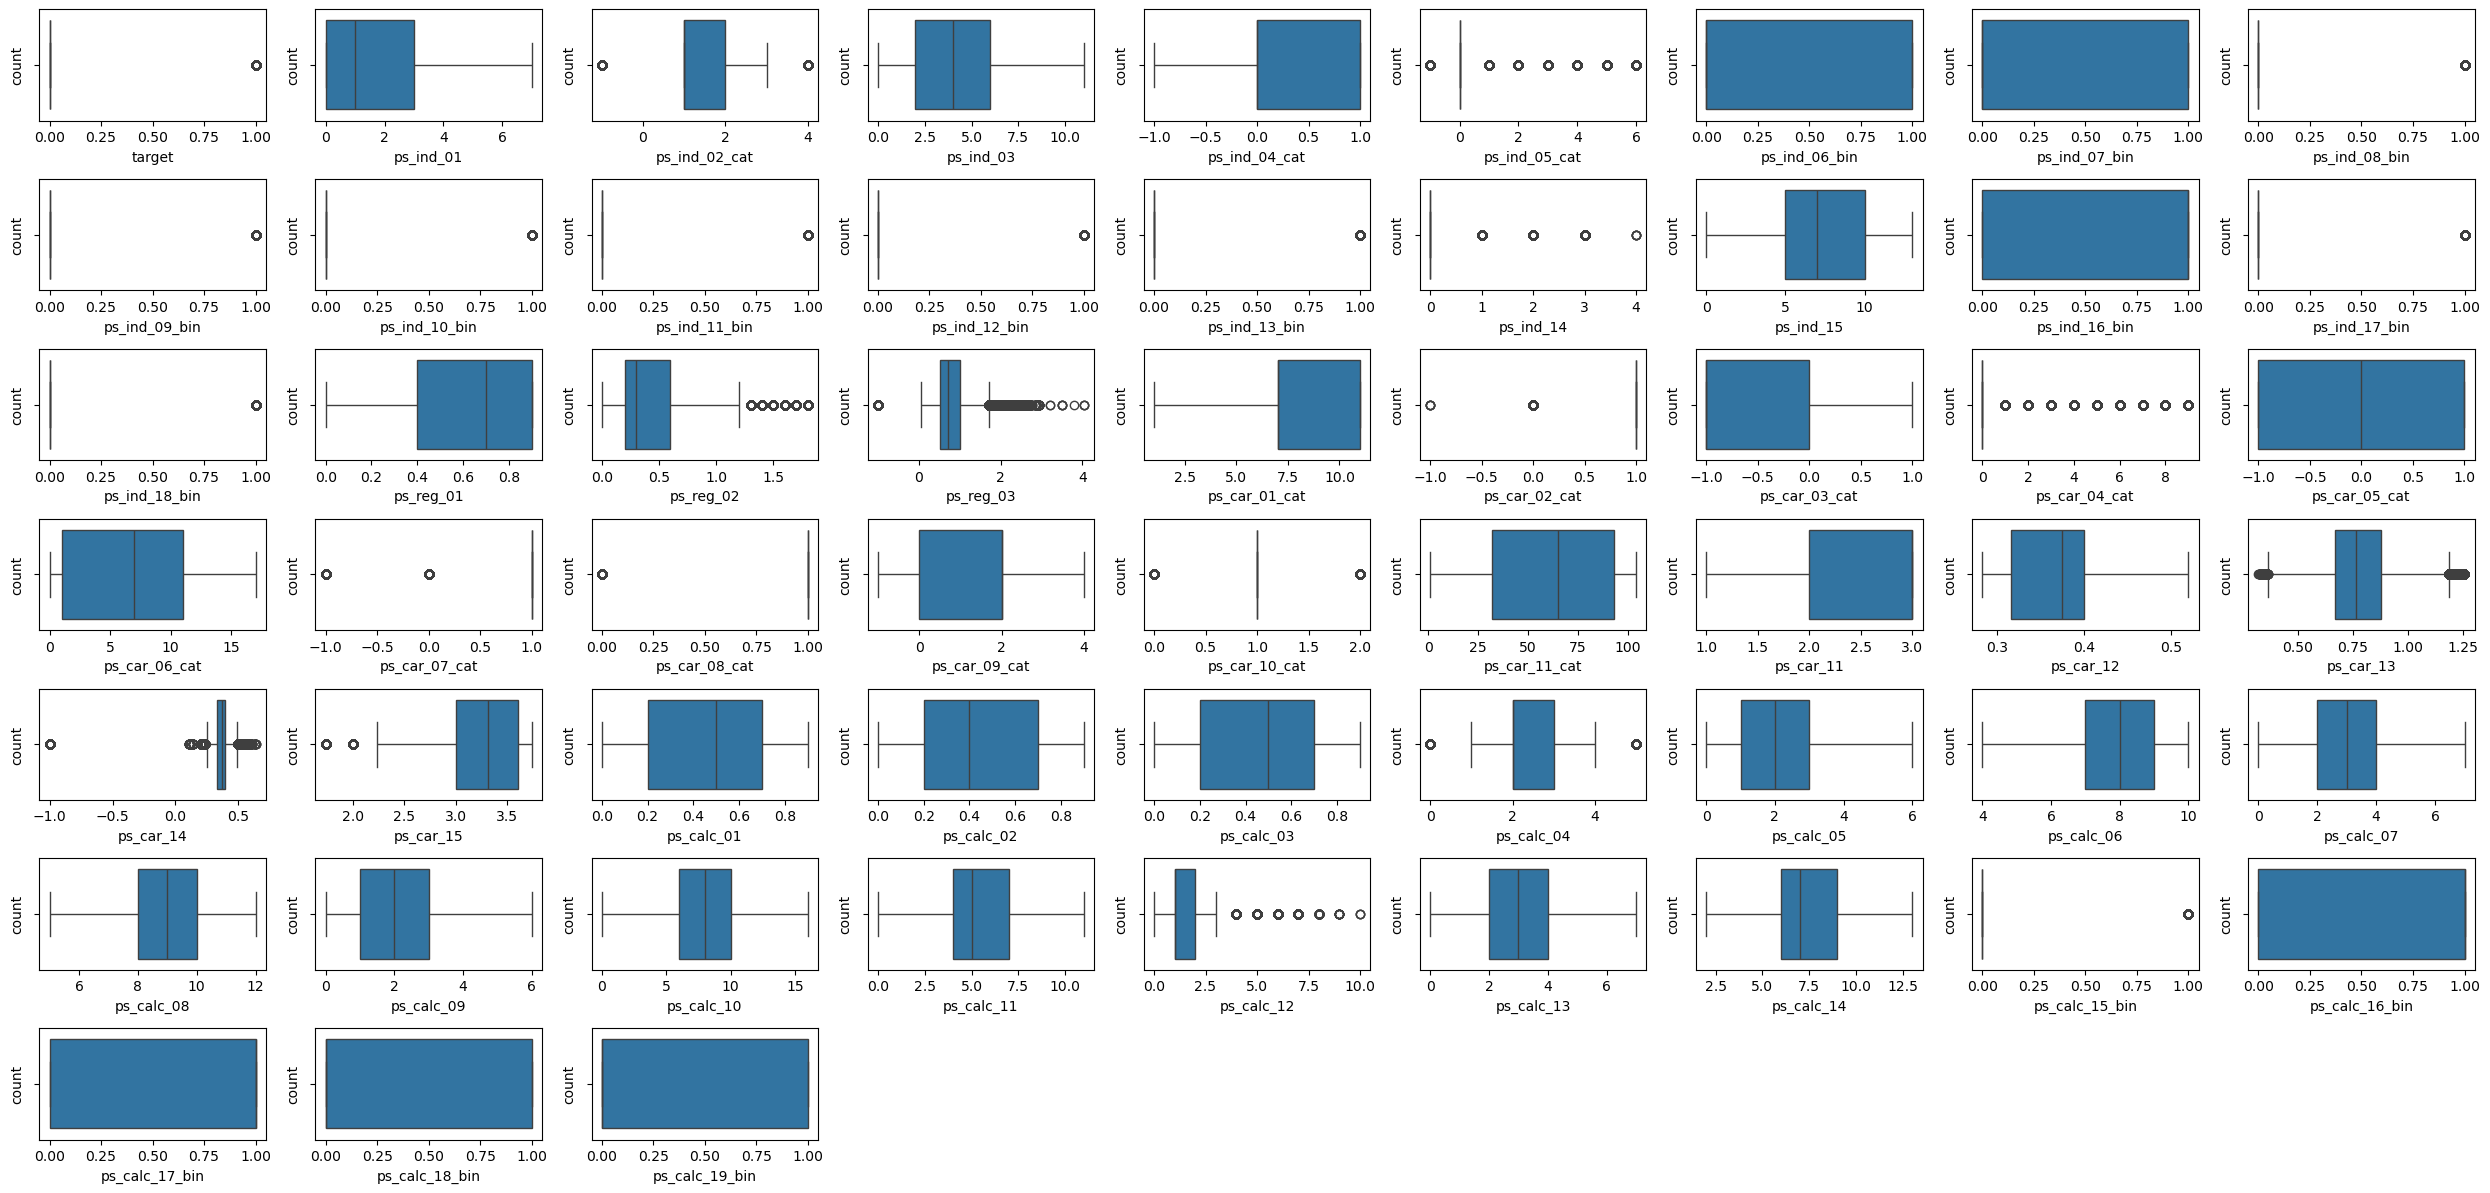

In [18]:
# Checking outliers handled or not
plt.figure(figsize=(25,15),facecolor='white')# to change the length and breadth of the canva
plotnumber=1
for i in data1:
    if plotnumber<=57:
        ax=plt.subplot(9,9,plotnumber)
        sns.boxplot(x=data1[i])
        plt.xlabel(i,fontsize=10)
        plt.ylabel("count",fontsize=10)
        plotnumber+=1
    plt.tight_layout()

## Feature Engineering

<Axes: >

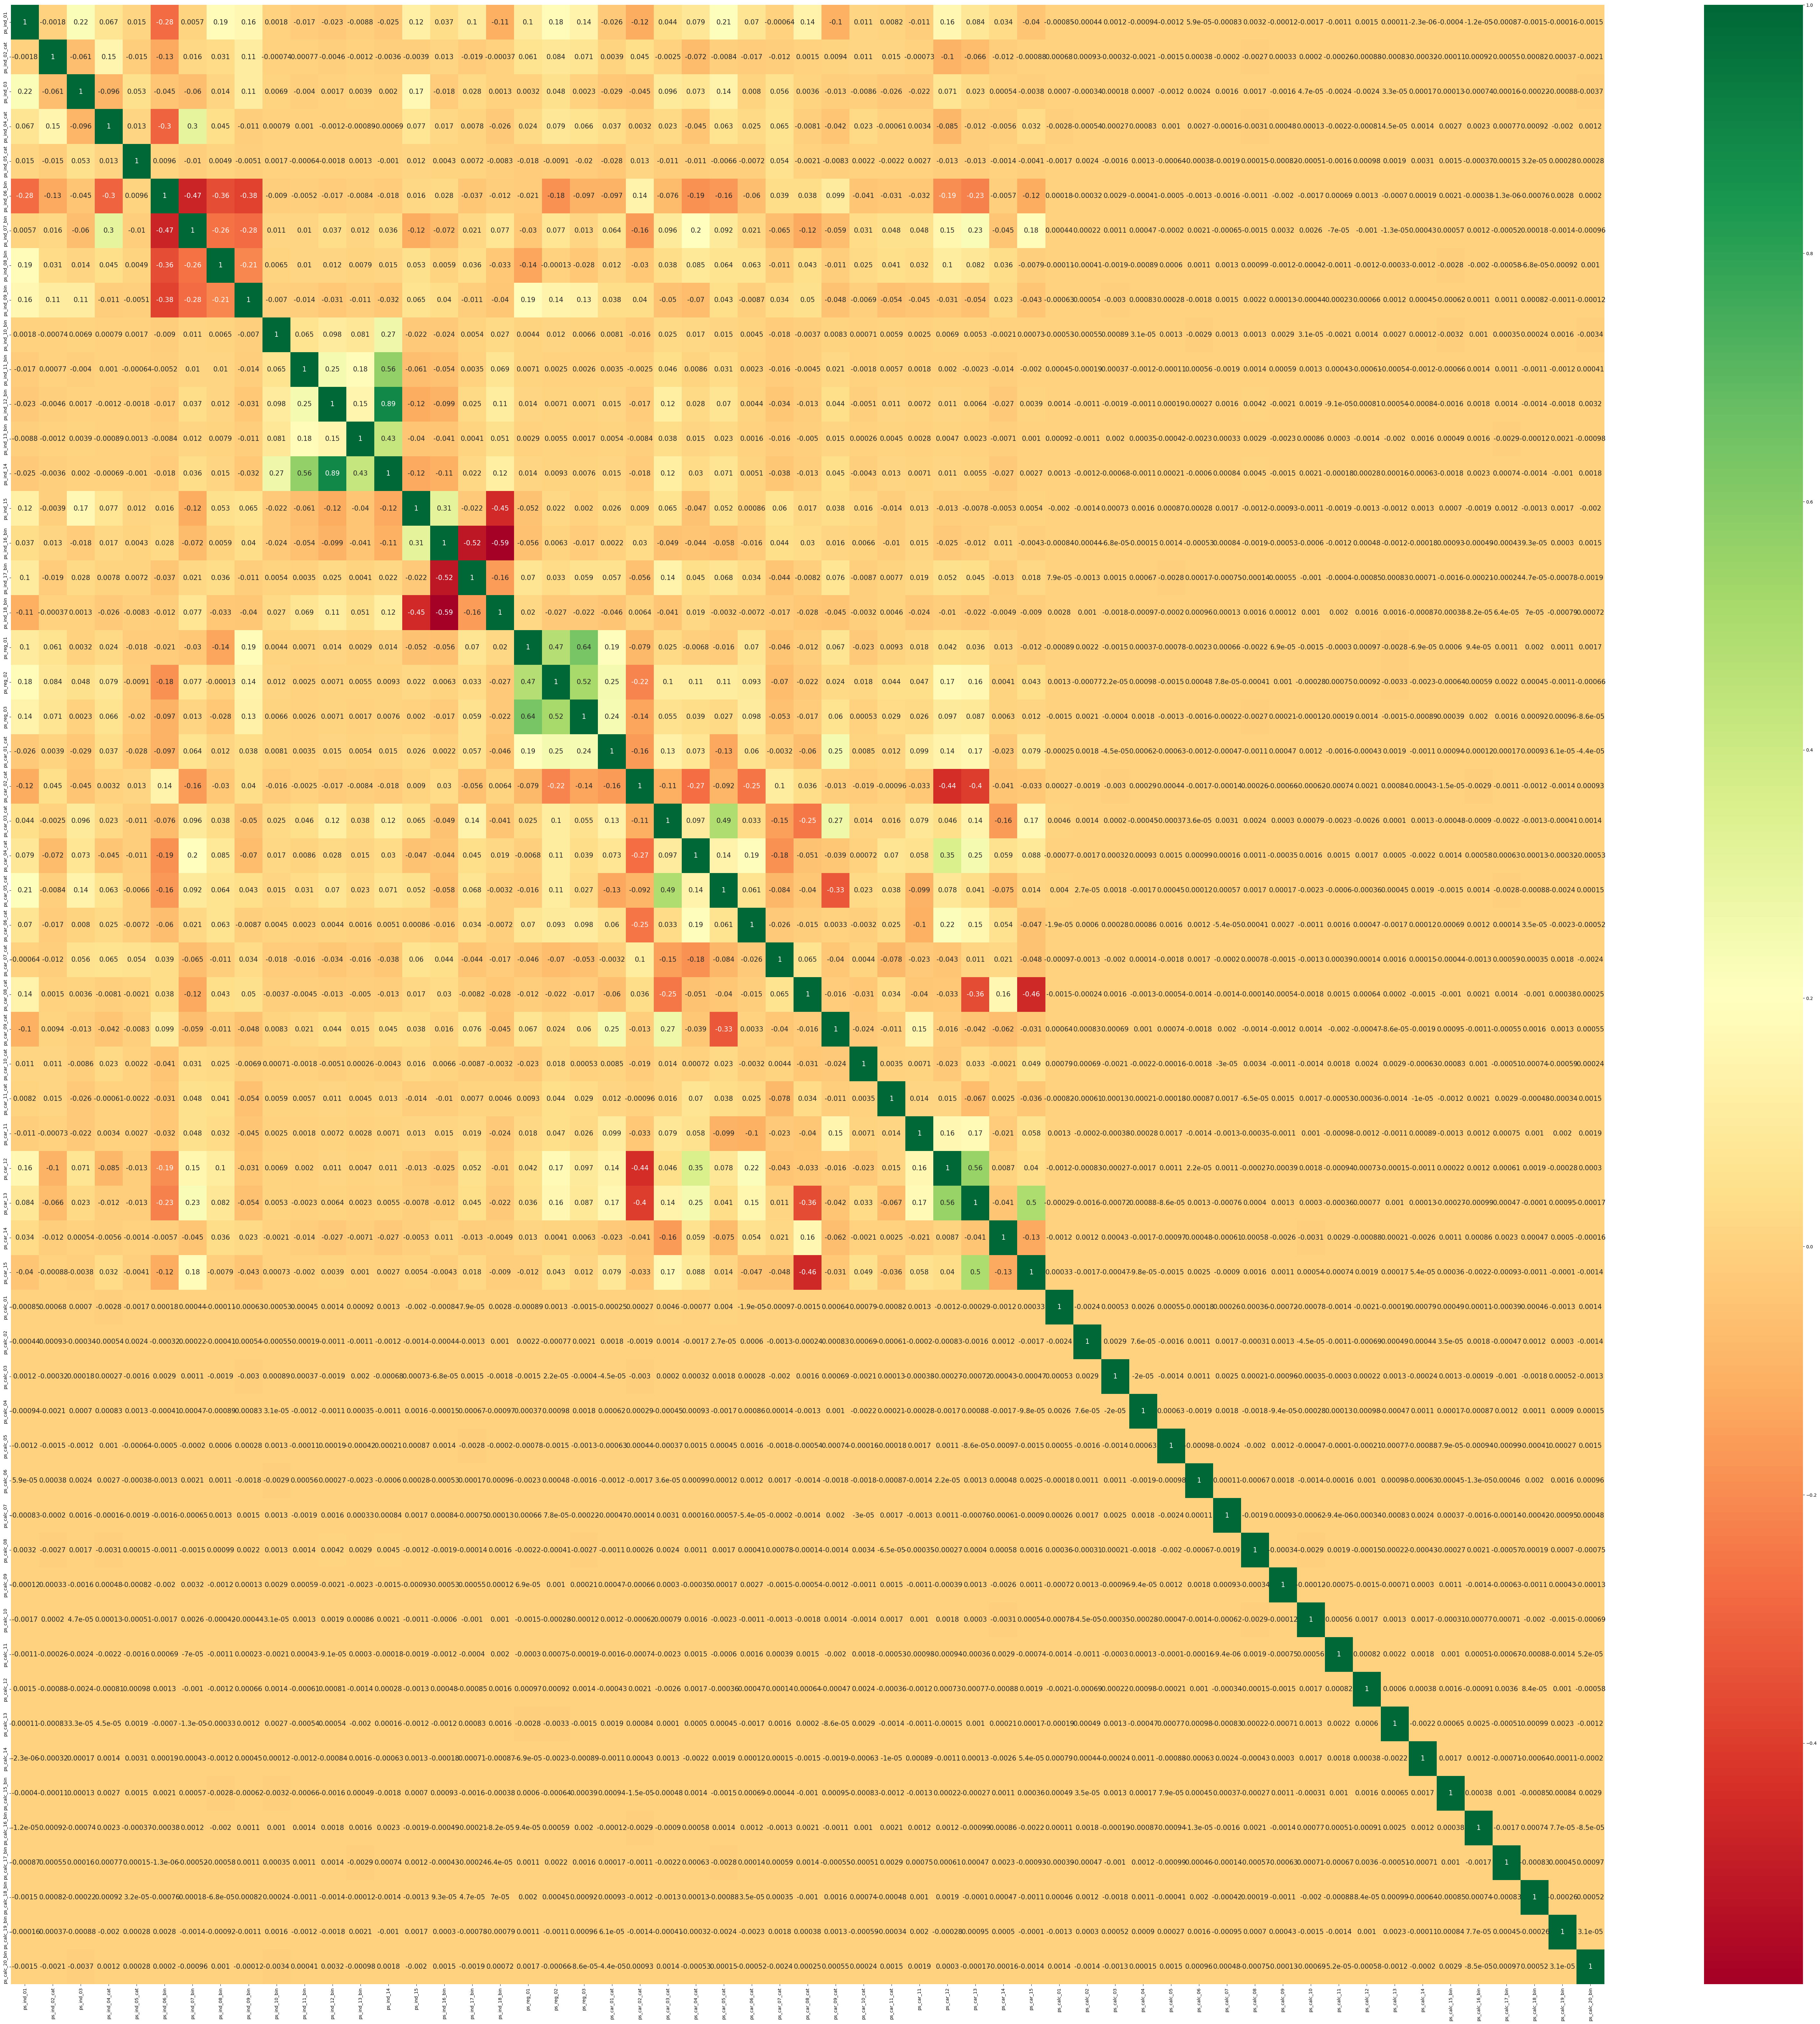

In [84]:
## Checking correlation


plt.figure(figsize=(80, 80))#canvas size
sns.heatmap(data1.drop('target', axis=1).corr(), annot=True, cmap="RdYlGn", annot_kws={"size":15})#plotting heat map to check correlation

In [21]:
# To find out whether the data is continous or discrete -checked with help of value count
for column in data1.columns:
    print(f"Value counts for column: {column}")
    print(data1[column].value_counts())
    print("\n")

Value counts for column: target
target
0    573518
1     21694
Name: count, dtype: int64


Value counts for column: ps_ind_01
ps_ind_01
0    187594
1    143984
2     82468
5     61464
3     51193
4     33524
6     17682
7     17303
Name: count, dtype: int64


Value counts for column: ps_ind_02_cat
ps_ind_02_cat
 1    431859
 2    123573
 3     28186
 4     11378
-1       216
Name: count, dtype: int64


Value counts for column: ps_ind_03
ps_ind_03
2     96110
3     81973
1     67994
4     67213
5     62803
6     60406
7     52364
8     39667
9     25436
0     15514
10    14484
11    11248
Name: count, dtype: int64


Value counts for column: ps_ind_04_cat
ps_ind_04_cat
 0    346965
 1    248164
-1        83
Name: count, dtype: int64


Value counts for column: ps_ind_05_cat
ps_ind_05_cat
 0    528009
 6     20662
 4     18344
 1      8322
 3      8233
-1      5809
 2      4184
 5      1649
Name: count, dtype: int64


Value counts for column: ps_ind_06_bin
ps_ind_06_bin
0    360852
1    23

## Prediction:
These are the continous columns 
'ps_reg_03','ps_car_11_cat','ps_car_12','ps_car_13','ps_car_14','ps_car_15'

Signs That Suggest It Might Be Scaled:
Centered Around Zero: The values appear to be distributed around 0, with both positive and negative values. This is a characteristic of standardization (z-score scaling).

Small Range: The values seem to be within a limited range , which is typical of standard scaling (where data is transformed to have mean = 0 and standard deviation = 1).
The column need to be scale :
ps_car_11_cat

In [22]:
## SCALING
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
data1[['ps_car_11_cat']]=scaler.fit_transform(data1[['ps_car_11_cat']])
data1

,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,0,2,2,5,1,0,0,1,0,0,0,0,0,0,0,11,0,1,0,0.7,0.2,0.718070,10,1,-1,0,1,4,1,0,0,1,0.106796,2,0.400000,0.883679,0.370810,3.605551,0.6,0.5,0.2,3,1,10,1,10,1,5,9,1,5,8,0,1,1,0,0,1
1,0,1,1,7,0,0,0,0,1,0,0,0,0,0,0,3,0,0,1,0.8,0.4,0.766078,11,1,-1,0,-1,11,1,1,2,1,0.174757,3,0.316228,0.618817,0.388716,2.449490,0.3,0.1,0.3,2,1,9,5,8,1,7,3,1,1,9,0,1,1,0,1,0
2,0,5,4,9,1,0,0,0,1,0,0,0,0,0,0,12,1,0,0,0.0,0.0,-1.000000,7,1,-1,0,-1,14,1,1,2,1,0.572816,1,0.316228,0.641586,0.347275,3.316625,0.5,0.7,0.1,2,2,9,1,8,2,7,4,2,7,7,0,1,1,0,1,0
3,0,0,1,2,0,0,1,0,0,0,0,0,0,0,0,8,1,0,0,0.9,0.2,0.580948,7,1,0,0,1,11,1,1,3,1,1.000000,1,0.374166,0.542949,0.294958,2.000000,0.6,0.9,0.1,2,4,7,1,8,4,2,2,2,4,9,0,0,0,0,0,0
4,0,0,2,0,1,0,1,0,0,0,0,0,0,0,0,9,1,0,0,0.7,0.6,0.840759,11,1,-1,0,-1,14,1,1,2,1,0.786408,3,0.316070,0.565832,0.365103,2.000000,0.4,0.6,0.0,2,2,6,3,10,2,12,3,1,1,3,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595207,0,3,1,10,0,0,0,0,0,1,0,0,0,0,0,13,1,0,0,0.5,0.3,0.692820,10,1,-1,0,1,1,1,1,0,1,0.291262,3,0.374166,0.684631,0.385487,2.645751,0.4,0.5,0.3,3,0,9,0,9,1,12,4,1,3,6,0,1,1,0,1,1
595208,0,5,1,3,0,0,0,0,0,1,0,0,0,0,0,6,1,0,0,0.9,0.7,1.382027,9,1,-1,0,-1,15,0,0,2,1,0.601942,2,0.387298,0.972145,-1.000000,3.605551,0.2,0.2,0.0,2,4,8,6,8,2,12,4,1,3,8,1,0,1,0,1,1
595209,0,1,1,10,0,0,1,0,0,0,0,0,0,0,0,12,1,0,0,0.9,0.2,0.659071,7,1,-1,0,-1,1,1,1,2,1,0.291262,3,0.397492,0.596373,0.398748,1.732051,0.4,0.0,0.3,3,2,7,4,8,0,10,3,2,2,6,0,0,1,0,0,0
595210,0,5,2,3,1,0,0,0,1,0,0,0,0,0,0,12,1,0,0,0.9,0.4,0.698212,11,1,-1,0,-1,11,1,1,2,1,0.970874,3,0.374166,0.764434,0.384968,3.162278,0.0,0.7,0.0,4,0,9,4,9,2,11,4,1,4,2,0,1,1,1,0,0


# Model Creation

In [23]:
## Creating independent and dependent variable
x = data1.drop('target', axis=1)#independent variable
y = data1.target#dependent variable

In [24]:
# Split data for training and testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [25]:
x_train.shape

(476169, 57)

In [26]:
x_test.shape

(119043, 57)

In [27]:
y_train.shape

(476169,)

In [28]:
y_test.shape

(119043,)

In [29]:
y_test

256886    0
118785    0
56083     0
542002    0
349518    0
         ..
120455    0
566247    0
558253    0
267708    0
572502    0
Name: target, Length: 119043, dtype: int64

In [30]:
data.target.value_counts() # data is imbalanced

target
0    573518
1     21694
Name: count, dtype: int64

In [31]:
has_missing_values = x_test.isnull().values.any()
print(has_missing_values)

False


# SMOTE

In [32]:
## Balacing the data
from collections import Counter# importing counter to check count of each label
from imblearn.over_sampling import SMOTE #for balancing the data
sm=SMOTE()#object creation
x_smote,y_smote=sm.fit_resample(x_train,y_train)


In [33]:
print("actual",Counter(y_train))
print("after smote",Counter(y_smote))

actual Counter({0: 458860, 1: 17309})
after smote Counter({0: 458860, 1: 458860})


# 1)Logistic Algorithm

In [34]:
from sklearn.linear_model import LogisticRegression
model_LR=LogisticRegression()
model_LR.fit(x_smote,y_smote)

LogisticRegression()

In [35]:
y_predLR=model_LR.predict(x_test)
y_predLR

array([0, 0, 0, ..., 0, 0, 1], dtype=int64)

In [36]:
y_pred_trainLR=model_LR.predict(x_smote)
y_pred_trainLR

array([0, 0, 0, ..., 1, 1, 0], dtype=int64)

In [37]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, classification_report
acc_score_testLR=accuracy_score(y_test,y_predLR)
acc_score_trainLR=accuracy_score(y_smote, y_pred_trainLR)
precision_scoreLR=precision_score(y_test,y_predLR)
recall_scoreLR=recall_score(y_test,y_predLR)
f1_scoreLR=f1_score(y_test,y_predLR)
class_report_LR=classification_report(y_test,y_predLR)

In [38]:
print('acc_score_test:',acc_score_testLR)
print('acc_score_train:',acc_score_trainLR)
print('precision_score:',precision_scoreLR)
print('recall_score:',recall_scoreLR)
print('f1_score:',f1_scoreLR)
print(classification_report(y_test,y_predLR))

acc_score_test: 0.8926942365363776
acc_score_train: 0.8767957546964216
precision_score: 0.04233496999454446
recall_score: 0.08848346636259977
f1_score: 0.057269372693726936
              precision    recall  f1-score   support

           0       0.96      0.92      0.94    114658
           1       0.04      0.09      0.06      4385

    accuracy                           0.89    119043
   macro avg       0.50      0.51      0.50    119043
weighted avg       0.93      0.89      0.91    119043



In [39]:
#Cross validation for Logistic
from sklearn.model_selection import cross_val_score
scores_LR=cross_val_score(model_LR,x,y,cv=3,scoring='accuracy')
print(scores_LR)
print('cross validation score',scores_LR.mean())
print('standard deviation',scores_LR.std())

[0.96355416 0.96355416 0.96354912]
cross validation score 0.963552482140817
standard deviation 2.37598294786621e-06


## 2) Decision Tree

In [40]:
from sklearn.tree import DecisionTreeClassifier#importing decision tree from sklearn.tree
model_DT=DecisionTreeClassifier()#object creation for decision tree
model_DT.fit(x_smote,y_smote)

DecisionTreeClassifier()

In [41]:
y_predDT=model_DT.predict(x_test)
y_predDT

array([0, 0, 1, ..., 0, 0, 0], dtype=int64)

In [42]:
y_pred_trainDT=model_DT.predict(x_smote)
y_pred_trainDT

array([0, 0, 0, ..., 1, 1, 1], dtype=int64)

In [43]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, classification_report
acc_score_testDT=accuracy_score(y_test,y_predDT)
acc_score_trainDT=accuracy_score(y_smote, y_pred_trainDT)
precision_scoreDT=precision_score(y_test,y_predDT)
recall_scoreDT=recall_score(y_test,y_predDT)
f1_scoreDT=f1_score(y_test,y_predDT)
class_report_DT=classification_report(y_test,y_predDT)

In [44]:
print('acc_score_test:',acc_score_testDT)
print('acc_score_train:',acc_score_trainDT)
print('precision_score:',precision_scoreDT)
print('recall_score:',recall_scoreDT)
print('f1_score:',f1_scoreDT)
print(classification_report(y_test,y_predDT))

acc_score_test: 0.9056055374948548
acc_score_train: 1.0
precision_score: 0.047663057829416426
recall_score: 0.0823261117445838
f1_score: 0.060372940881344594
              precision    recall  f1-score   support

           0       0.96      0.94      0.95    114658
           1       0.05      0.08      0.06      4385

    accuracy                           0.91    119043
   macro avg       0.51      0.51      0.51    119043
weighted avg       0.93      0.91      0.92    119043



In [45]:
#Cross validation for DT
from sklearn.model_selection import cross_val_score
scores_DT=cross_val_score(model_DT,x,y,cv=3,scoring='accuracy')
print(scores_DT)
print('cross validation score',scores_DT.mean())
print('standard deviation',scores_DT.std())

[0.91754703 0.91771839 0.91940183]
cross validation score 0.918222414870668
standard deviation 0.0008368993106496333


# Hyperparameter Tuning -DT 

In [47]:
from sklearn.model_selection import RandomizedSearchCV

tree_clf = DecisionTreeClassifier(random_state=3)
param_dist = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": list(range(1, 20)),
    "min_samples_split": [2, 3, 4],
    "min_samples_leaf": list(range(1, 20)),
}

tree_cv = RandomizedSearchCV(tree_clf, param_dist, n_iter=50, scoring="accuracy", n_jobs=-1, verbose=1, cv=3, random_state=3)
tree_cv.fit(x_smote, y_smote)
best_params = tree_cv.best_params_
print(f"Best parameters: {best_params}")


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters: {'splitter': 'best', 'min_samples_split': 2, 'min_samples_leaf': 14, 'max_depth': 19, 'criterion': 'entropy'}


In [48]:
tree_cv.best_params_

{'splitter': 'best',
 'min_samples_split': 2,
 'min_samples_leaf': 14,
 'max_depth': 19,
 'criterion': 'entropy'}

In [49]:
tree_cv.best_score_#getting best score form cv

0.9414189684843078

In [50]:
DT=DecisionTreeClassifier(criterion='entropy',max_depth=19,min_samples_leaf= 14,min_samples_split=2,splitter='best')#passing best parameter to decision tree

In [51]:
DT.fit(x_smote,y_smote)

DecisionTreeClassifier(criterion='entropy', max_depth=19, min_samples_leaf=14)

In [52]:
new_y_predDT=DT.predict(x_test)
new_y_predDT
new_y_pred_trainDT=DT.predict(x_smote)

In [53]:
new_acc_score_testDT=accuracy_score(y_test,new_y_predDT)
new_acc_score_trainDT=accuracy_score(y_smote, new_y_pred_trainDT)
new_precision_scoreDT=precision_score(y_test,new_y_predDT)
new_recall_scoreDT=recall_score(y_test,new_y_predDT)
new_f1_scoreDT=f1_score(y_test,new_y_predDT)
new_class_report_DT=classification_report(y_test,new_y_predDT)

In [54]:
print('acc_score_test:',new_acc_score_testDT)
print('acc_score_train:',new_acc_score_trainDT)
print('precision_score:',new_precision_scoreDT)
print('recall_score:',new_recall_scoreDT)
print('f1_score:',new_f1_scoreDT)
print(classification_report(y_test,new_y_predDT))

acc_score_test: 0.9303444973664978
acc_score_train: 0.9543967658980953
precision_score: 0.05019571724614322
recall_score: 0.049714937286202965
f1_score: 0.04995417048579285
              precision    recall  f1-score   support

           0       0.96      0.96      0.96    114658
           1       0.05      0.05      0.05      4385

    accuracy                           0.93    119043
   macro avg       0.51      0.51      0.51    119043
weighted avg       0.93      0.93      0.93    119043



## 3) RandomForest Algorithmn

In [56]:
from sklearn.ensemble import RandomForestClassifier
model_RF=RandomForestClassifier()
model_RF.fit(x_smote,y_smote)

RandomForestClassifier()

In [57]:
y_predRF=model_RF.predict(x_test)
y_predRF

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [58]:
y_train_predRF=model_RF.predict(x_smote)
y_train_predRF

array([0, 0, 0, ..., 1, 1, 1], dtype=int64)

In [59]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, classification_report
acc_score_testRF=accuracy_score(y_test,y_predRF)
acc_score_trainRF=accuracy_score(y_smote, y_train_predRF)
precision_scoreRF=precision_score(y_test,y_predRF)
recall_scoreRF=recall_score(y_test,y_predRF)
f1_scoreRF=f1_score(y_test,y_predRF)
class_reportRF=classification_report(y_test,y_predRF)

In [60]:
print('acc_score_test:',acc_score_testRF)
print('acc_score_train:',acc_score_trainRF)
print('precision_score:',precision_scoreRF)
print('recall_score:',recall_scoreRF)
print('f1_score:',f1_scoreRF)
print(classification_report(y_test,y_predRF))

acc_score_test: 0.9622237342808901
acc_score_train: 0.9999934620581441
precision_score: 0.07575757575757576
recall_score: 0.002280501710376283
f1_score: 0.004427717511622758
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114658
           1       0.08      0.00      0.00      4385

    accuracy                           0.96    119043
   macro avg       0.52      0.50      0.49    119043
weighted avg       0.93      0.96      0.94    119043



In [61]:
#Cross validation for Random Forest
from sklearn.model_selection import cross_val_score
scores_RF=cross_val_score(model_RF,x,y,cv=3,scoring='accuracy')
print(scores_RF)
print('cross validation score',scores_RF.mean())
print('standard deviation',scores_RF.std())

[0.96355416 0.96355416 0.9635592 ]
cross validation score 0.9635558422881259
standard deviation 2.3759829479185465e-06


# 4) XG BOOST

In [63]:
!pip install xgboost

In [75]:
from xgboost import XGBClassifier
model_XGB= XGBClassifier()
model_XGB.fit(x_smote, y_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [76]:
y_predXGB=model_XGB.predict(x_test)
y_predXGB

array([0, 0, 0, ..., 0, 0, 0])

In [77]:
y_pred_trainXGB=model_XGB.predict(x_smote)
y_pred_trainXGB

array([0, 0, 0, ..., 1, 1, 1])

In [78]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, classification_report
acc_score_testXGB=accuracy_score(y_test,y_predXGB)
acc_score_trainXGB=accuracy_score(y_smote, y_pred_trainXGB)
precision_scoreXGB=precision_score(y_test,y_predXGB)
recall_scoreXGB=recall_score(y_test,y_predXGB)
f1_scoreXGB=f1_score(y_test,y_predXGB)
class_reportXGB=classification_report(y_test,y_predXGB)

In [79]:
print('acc_score_test:',acc_score_testXGB)
print('acc_score_train:',acc_score_trainXGB)
print('precision_score:',precision_scoreXGB)
print('recall_score:',recall_scoreXGB)
print('f1_score:',f1_scoreXGB)
print(classification_report(y_test,y_predXGB))

acc_score_test: 0.9631393698075486
acc_score_train: 0.9808209475657064
precision_score: 0.2857142857142857
recall_score: 0.00045610034207525655
f1_score: 0.0009107468123861566
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114658
           1       0.29      0.00      0.00      4385

    accuracy                           0.96    119043
   macro avg       0.62      0.50      0.49    119043
weighted avg       0.94      0.96      0.95    119043



In [80]:
#Cross validation for Random Forest
from sklearn.model_selection import cross_val_score
scores_XGB=cross_val_score(model_XGB,x,y,cv=3,scoring='accuracy')
print(scores_XGB)
print('cross validation score',scores_XGB.mean())
print('standard deviation',scores_XGB.std())

[0.96350376 0.96349872 0.96352392]
cross validation score 0.963508800225802
standard deviation 1.0888121708572616e-05


In [70]:
!pip install tabulate

In [81]:
from tabulate import tabulate

In [82]:
Table = [["LR",acc_score_testLR,precision_scoreLR,recall_scoreLR,f1_scoreLR ],
        ["XGBoost", acc_score_testXGB,precision_scoreXGB,recall_scoreXGB,f1_scoreXGB],
        ["Decision Tree", acc_score_testDT,precision_scoreDT,recall_scoreDT,f1_scoreDT],
        ["Decision Tree_HT", new_acc_score_testDT,new_precision_scoreDT,new_recall_scoreDT,new_f1_scoreDT],
        ["Random Forest", acc_score_testRF,precision_scoreRF,recall_scoreRF,f1_scoreRF]]
        

col_names1 = ["Algorithm", "Accuracy Score", "Precision Score", "recall Score", "F1 Score"]

print(tabulate(Table, headers = col_names1, tablefmt = "fancy_grid"))

╒══════════════════╤══════════════════╤═══════════════════╤════════════════╤═════════════╕
│ Algorithm        │   Accuracy Score │   Precision Score │   recall Score │    F1 Score │
╞══════════════════╪══════════════════╪═══════════════════╪════════════════╪═════════════╡
│ LR               │         0.892694 │         0.042335  │      0.0884835 │ 0.0572694   │
├──────────────────┼──────────────────┼───────────────────┼────────────────┼─────────────┤
│ XGBoost          │         0.963139 │         0.285714  │      0.0004561 │ 0.000910747 │
├──────────────────┼──────────────────┼───────────────────┼────────────────┼─────────────┤
│ Decision Tree    │         0.905606 │         0.0476631 │      0.0823261 │ 0.0603729   │
├──────────────────┼──────────────────┼───────────────────┼────────────────┼─────────────┤
│ Decision Tree_HT │         0.930344 │         0.0501957 │      0.0497149 │ 0.0499542   │
├──────────────────┼──────────────────┼───────────────────┼────────────────┼─────────────┤

## Conclusion: XGBoost and Random Forest  seems to best for this data set involving insurance claim
